<a href="https://colab.research.google.com/github/hitarthmehtaa/Quant_learning_journey-/blob/main/Week1_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Adding the stock data from yahoo finance


In [2]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

Adding 4 companies here initially
  1) Apple
  2) Tesla
  3) Reliance
  4) TCS


In [3]:
company = ['AAPL','TSLA','NVDA']

all_data = {}

for i in range(len(company)):
  ticker = yf.Ticker(company[i])
  historical_data = ticker.history(period='1y')
  historical_data['Volume(in cr)'] = historical_data['Volume']/1000000
  print(company[i],'s Stock Data over 1 Year')
  all_data[company[i]] = historical_data
  print(historical_data[['Open','High','Low','Close','Volume(in cr)']])


AAPL s Stock Data over 1 Year
                                 Open        High         Low       Close  \
Date                                                                        
2025-06-17 00:00:00-04:00  196.420746  197.606046  194.438619  194.866913   
2025-06-18 00:00:00-04:00  195.165737  196.789301  194.299180  195.803207   
2025-06-20 00:00:00-04:00  197.456661  200.902980  196.082109  200.205750   
2025-06-23 00:00:00-04:00  200.833242  201.500592  198.173794  200.703751   
2025-06-24 00:00:00-04:00  201.789459  202.636106  199.408903  199.508514   
...                               ...         ...         ...         ...   
2026-06-10 00:00:00-04:00  290.739990  294.750000  287.380005  291.579987   
2026-06-11 00:00:00-04:00  293.720001  297.000000  289.589996  295.630005   
2026-06-12 00:00:00-04:00  296.029999  297.140015  289.619995  291.130005   
2026-06-15 00:00:00-04:00  294.119995  297.779999  291.700012  296.420013   
2026-06-16 00:00:00-04:00  295.250000  300.480

Plotting the close values for apple

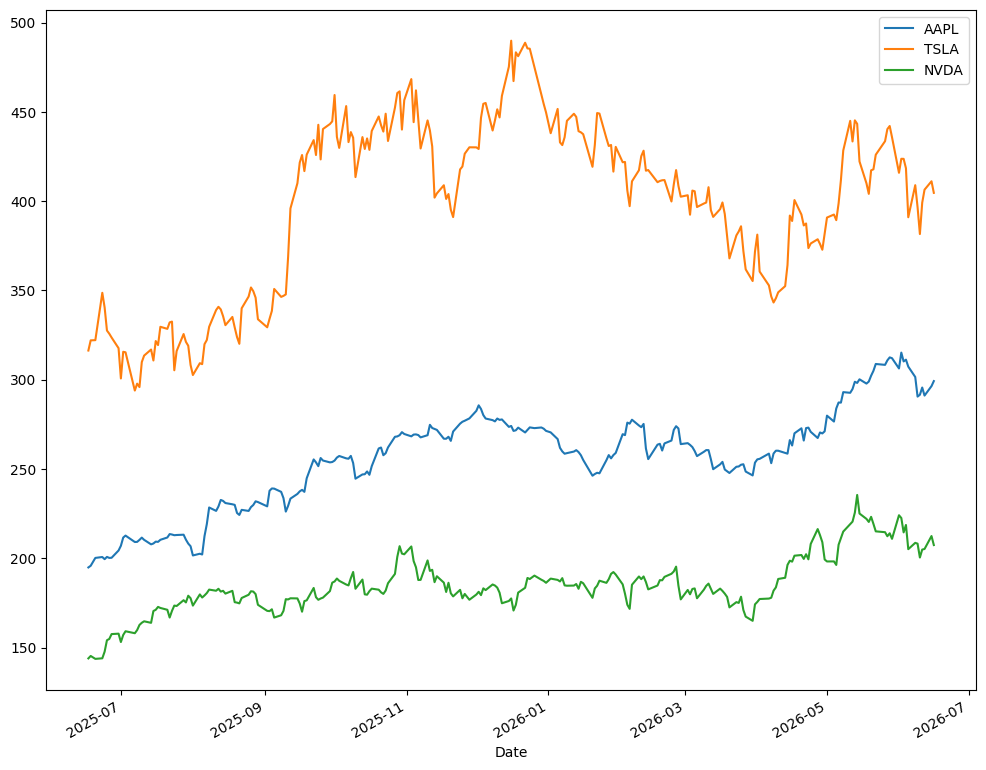

In [4]:
df = pd.DataFrame()

for i in range(len(company)):
  df[company[i]] = all_data[company[i]]['Close']

df.plot(figsize=(12,10))
plt.show()

Daily Return Formulae = (P_t - P_t-1)/ P_t-1

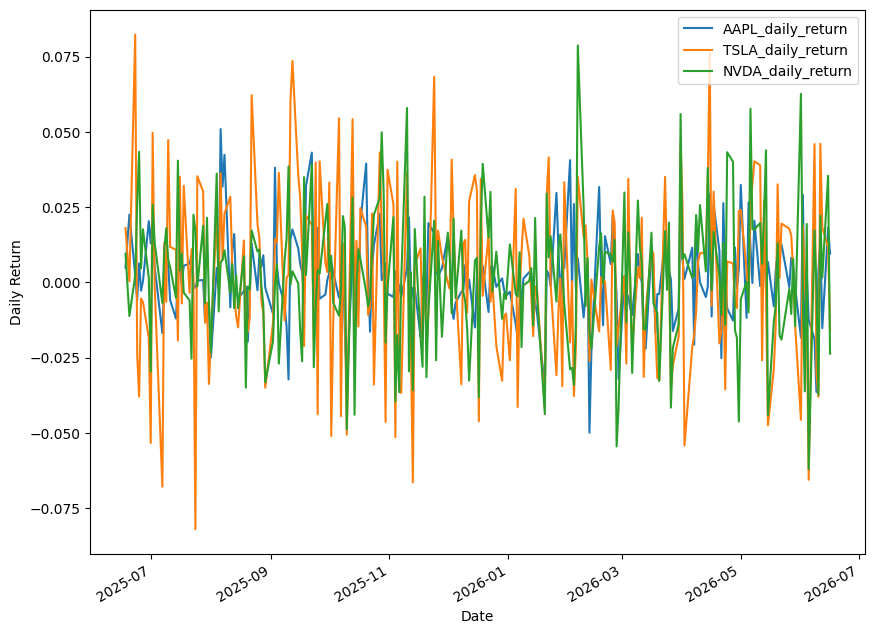

In [5]:
for i in range (len(company)):
  df[f'{company[i]}_daily_return'] =  all_data[company[i]]['Close'].pct_change()

df[['AAPL_daily_return','TSLA_daily_return','NVDA_daily_return']].plot(figsize=(10,8))
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.show()



Moving Average


<Axes: xlabel='Date'>

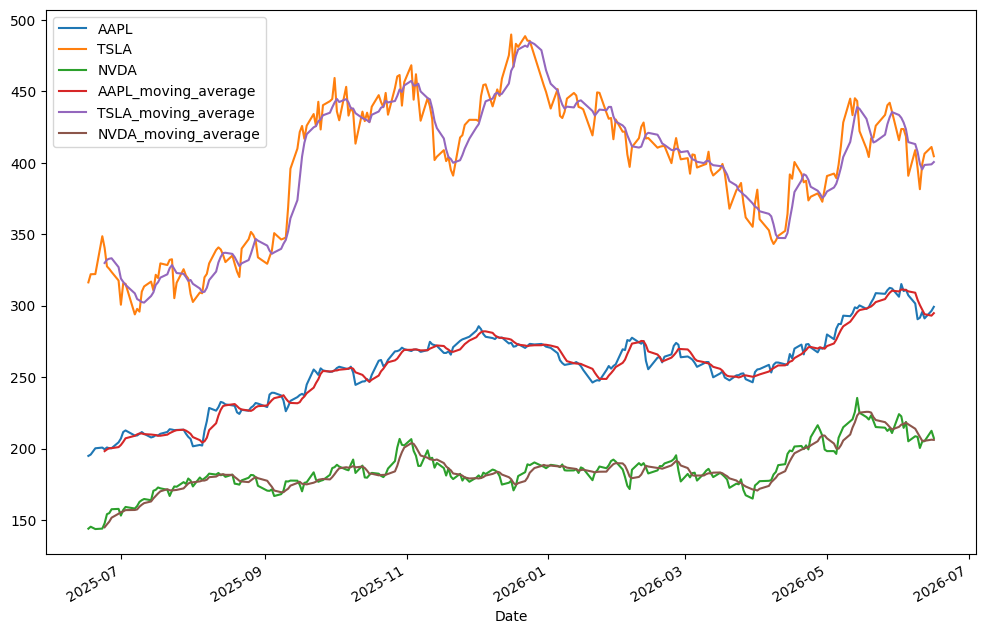

In [6]:
for i in range(len(company)):
  df[f"{company[i]}_moving_average"] = df[company[i]].rolling(window=5).mean()

df[['AAPL','TSLA','NVDA','AAPL_moving_average','TSLA_moving_average','NVDA_moving_average']].plot(figsize=(12,8))




Volatility

<Axes: xlabel='Date'>

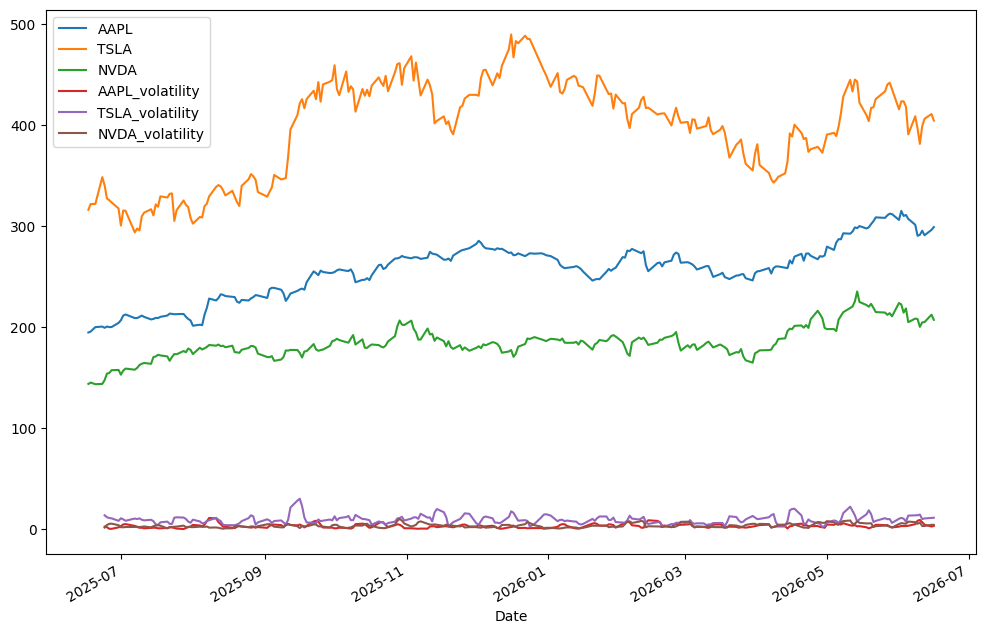

In [7]:
for i in range(len(company)):
  df[f"{company[i]}_volatility"] = df[company[i]].rolling(window=5).std()

df[['AAPL','TSLA','NVDA','AAPL_volatility','TSLA_volatility','NVDA_volatility']].plot(figsize=(12,8))



In [8]:
print(df['AAPL_volatility'].mean())
print(df['TSLA_volatility'].mean())
print(df['NVDA_volatility'].mean())

3.2627877121938043
9.571878573826188
3.6398605431459403


AS WE CAN SEE THAT TESLA HAS THE HIGHEST VOLATILITY FOLLOWED BY NVIDIA AND THE LAST IS APPLE WITH THE LOWEST OUT OF THE 3. THIS SHOWS THAT APPLE IS A SAFER STOCK TO INVEST IN RIGHT NOW FOR INVESTORS LOOKING FOR LOW VOLATILE OPTIONS.

NOW SHALL LOOK INTO CUMPROD

In [9]:
apple_cumulative_returns = (1+df['AAPL_daily_return']).cumprod()
tesla_cumulative_returns = (1+df['TSLA_daily_return']).cumprod()
nvidia_cumulative_returns = (1+df['NVDA_daily_return']).cumprod()

print(apple_cumulative_returns[-1])
print(tesla_cumulative_returns[-1])
print(nvidia_cumulative_returns[-1])

1.5356121050540439
1.2791528239443035
1.441064941112013


/tmp/ipykernel_1668/2552868024.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(apple_cumulative_returns[-1])
/tmp/ipykernel_1668/2552868024.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(tesla_cumulative_returns[-1])
/tmp/ipykernel_1668/2552868024.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(nvidia_cumulative_returns[-1])


In [10]:
summary = pd.DataFrame ({
    'Company':['Apple','Tesla','Nvidia'],
    'Average Daily Return':[df['AAPL_daily_return'].mean(),df['TSLA_daily_return'].mean(),df['NVDA_daily_return'].mean()],
    'Volatility':[df['AAPL_volatility'].mean(),df['TSLA_volatility'].mean(),df['NVDA_volatility'].mean()],
    'Cumulative Returns':[apple_cumulative_returns[-1],tesla_cumulative_returns[-1],nvidia_cumulative_returns[-1]]
})

/tmp/ipykernel_1668/3687648386.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Cumulative Returns':[apple_cumulative_returns[-1],tesla_cumulative_returns[-1],nvidia_cumulative_returns[-1]]


In [11]:
summary

,Company,Average Daily Return,Volatility,Cumulative Returns
0,Apple,0.001818,3.262788,1.535612
1,Tesla,0.001375,9.571879,1.279153
2,Nvidia,0.001708,3.639861,1.441065


NOW WE SHALL MOVE ON FROM INDIVIDUAL STOCK ANALYSIS TO START TO MAKE A PORTFOLIO WITH THESE 3 STOCKS AND SEE THE PERFORMANCE.

In [12]:
returns = pd.DataFrame ()

returns['APPLE'] = df['AAPL_daily_return']
returns['TESLA'] = df['TSLA_daily_return']
returns['NVDA'] = df['NVDA_daily_return']

returns = returns.dropna()

In [13]:
returns

,APPLE,TESLA,NVDA
Date,,,
2025-06-18 00:00:00-04:00,0.004805,0.018018,0.009437
2025-06-20 00:00:00-04:00,0.022485,0.000342,-0.011204
2025-06-23 00:00:00-04:00,0.002487,0.082319,0.002225
2025-06-24 00:00:00-04:00,-0.005955,-0.023546,0.025872
2025-06-25 00:00:00-04:00,0.006291,-0.037948,0.043340
...,...,...,...
2026-06-10 00:00:00-04:00,0.003545,-0.038041,-0.037322
2026-06-11 00:00:00-04:00,0.013890,0.046018,0.022203
2026-06-12 00:00:00-04:00,-0.015222,0.018239,0.001562


In [14]:
correlation = returns.corr()
print(correlation)

          APPLE     TESLA      NVDA
APPLE  1.000000  0.286222  0.188843
TESLA  0.286222  1.000000  0.366263
NVDA   0.188843  0.366263  1.000000


SINCE THE CORRELATION IS LOW, DEVELOPING A PORTFOLIO WILL BE BETTER FOR US.

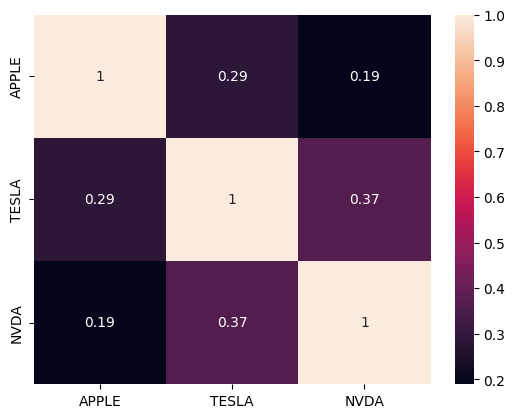

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(correlation,annot=True)
plt.show()

SO APPLE HAS A MID CORRELATION WITH TESLA AT 0.29 WHILE HAS A LOW CORRELATION WITH NVIDIA STOCK AT 0.19. LASTLY TESLA HAS THE HIGHEST CORRELATION WITH NVIDIA AT 0.33.

NOW MOVING ON WITH BUILDING AN ELEMENTARY PORTFOLIO WITH THESE 3 STOCKS.
FURTHER PORTFOLIO ANALYSIS SHALL BE CONDUCTED LIKE CALCULATING THE SHARPE RATIO, VOLATILITY ETC.

In [16]:
weights = [0.33,0.33,0.33]

portfolio_returns = (
    weights[0]*df['AAPL_daily_return']+ weights[1]*df['TSLA_daily_return']+ weights[2]*df['NVDA_daily_return']
)

In [17]:
portfolio_returns_volatility = portfolio_returns.std()

print(portfolio_returns_volatility)

0.015770959690971788


SO AS WE CAN SEE, WE HAVE ACHIEVED TO GET THE VOLATILITY DOWN INSTEAD OF HOLDING ONE WHICH WOULD HAVE BEEN ABOVE 1.

In [18]:
portfolio_returns

,0
Date,
2025-06-17 00:00:00-04:00,NaN
2025-06-18 00:00:00-04:00,0.010646
2025-06-20 00:00:00-04:00,0.003835
2025-06-23 00:00:00-04:00,0.028720
2025-06-24 00:00:00-04:00,-0.001198
...,...
2026-06-10 00:00:00-04:00,-0.023700
2026-06-11 00:00:00-04:00,0.027097
2026-06-12 00:00:00-04:00,0.001511


WE SHALL BE USING THE PORTFOLIO RISK FORMULAE WHICH IS

$$
\sigma_p = \sqrt{w^T \Sigma w}
$$

1.452205754220976


/tmp/ipykernel_1668/4293091100.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(portfolio_cumulative[-1])


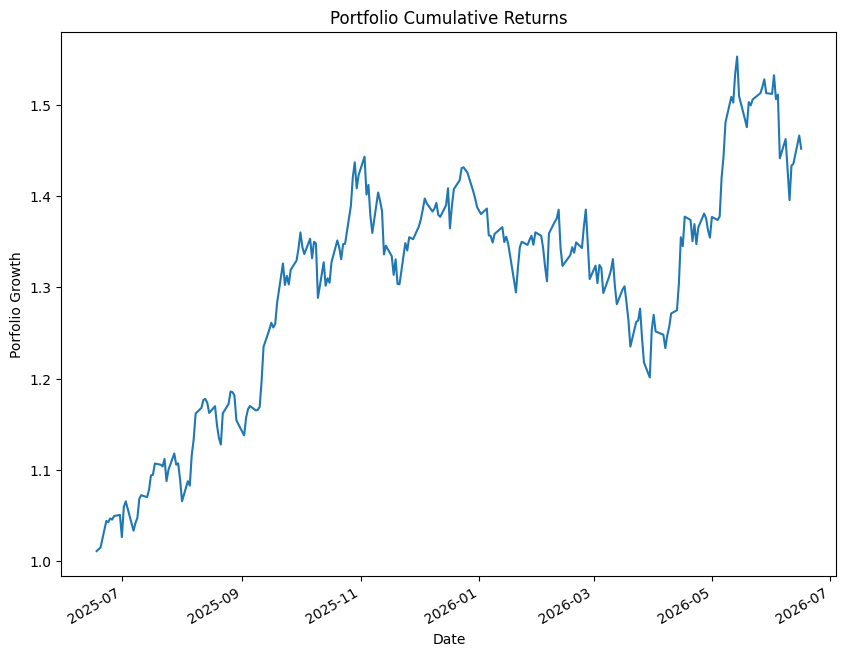

In [19]:
portfolio_cumulative = (1 + portfolio_returns).cumprod()

print(portfolio_cumulative[-1])
portfolio_cumulative.plot(figsize=(10,8))
plt.title('Portfolio Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Porfolio Growth')
plt.show()

THIS SHOWS THAT THE PORTFOLIO STILL PERFORMED RELATIVELY STRONG COMPARED TO INDIVIDUAL STOCKS. THIS ALSO SHOWS INVESTING IN A PORTFOLIO LIKE THIS HELPS US TO MANAGE RISK AND GET GOOD RETURNS.

SHARPE RATIO

$$
R_p-R_f/σ_p
$$

In [20]:
sharpe_ratio = portfolio_returns.mean()/ portfolio_returns_volatility
print(sharpe_ratio)

0.10255426289972527


SHARPE RATIO SHOWS POSITIVE RETURNS ACCOUNTING FOR THE RATE OF RISK. EVEN THOUGH TAKEN AS 0, WE SAW POSTIVE RETURNS.

* **CONCLUSION**

* **The equal-weight portfolio demonstrated moderate volatility with positive cumulative growth over the analyzed period. Diversification across Apple, Tesla, and Nvidia reduced overall portfolio risk relative to highly volatile individual equities. The positive Sharpe Ratio indicated favorable risk-adjusted performance.**

DAY 4 - We shall be working with CAPM and Beta Analysis

To further elaborate on that, I will define these concepts accordingly.

CAPM or Capital Asset Pricing Model is the estimated return based on the risk that the investor is taking. Since some stocks are more volatile than others, they expect higher returns in proportion to the risk.

CAPM oftens answer the question of "am i being compensated enough for the risk I am taking? "

The Formulae for calculating CAPM is:-
$$
E(R_i)=β(E(R_m)-R_f)
$$
Where
$$
E(R_i)=expectedreturnof the stock
$$
$$
β_i =  the beta of the stock
$$
$$
E(R_m) = the expected market return
$$
$$
R_f = the risk free rate
$$

Now Lets move on to beta.

Beta is a measure of the sensitivity a stock has relative to the market.

$$
β_i= Cov(R_i,R_m)/ Var(R_m)
$$

1) If the β =1 ,  then the stock moves with the market.

2) If the β > 1, then the stock is more volatile than the market.

3) If the β < 1 \, then it is relatively less volatile.

4) If the β < 0 , then it moves opposite to the market.


What this pricing model essentially does is give the investors an intersting insight of emphasizing systematic market risk.
Diversifying gets rid of the company based risk associated with individual stocks.
But market crashes affect everything.


In [21]:
spy = yf.Ticker('SPY')
market = spy.history(period='1y')


In [22]:
market['Returns'] = market['Close'].pct_change()


In [23]:
capm = pd.DataFrame({
    'Apple': df['AAPL_daily_return'],
    'Tesla': df['TSLA_daily_return'],
    'NVDA' : df['NVDA_daily_return'],
    'Market': market['Returns']
})

In [24]:
capm = capm.dropna()

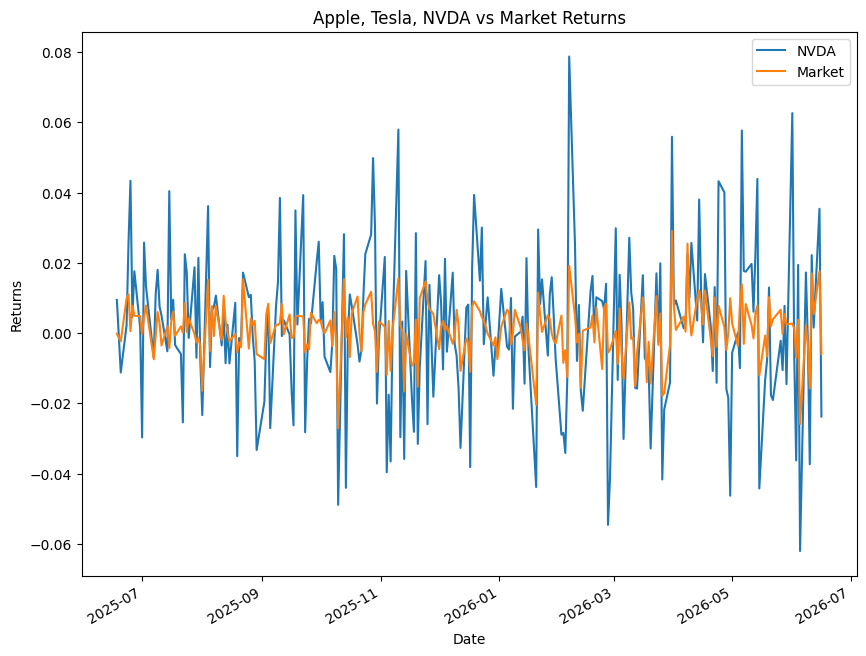

In [25]:
capm[['NVDA','Market']].plot(figsize=(10,8))
plt.title('Apple, Tesla, NVDA vs Market Returns')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.show()

In [26]:
apple_covariance = capm['Apple'].cov(capm['Market'])
tesla_covariance = capm.cov().iloc[1,3]
nvda_covariance = capm.cov().iloc[2,3]

market_variance = capm['Market'].var()

apple_beta =  apple_covariance/market_variance
tesla_beta =  tesla_covariance/market_variance
nvda_beta  =  nvda_covariance/ market_variance

In [27]:
print(apple_beta,tesla_beta,nvda_beta)

0.8887497630186286 2.032878767267402 1.8476618509000347


So to evaluate the beta values

Apple moves very closely with the market, if the market increases 1% then the stock increases 0.96%

For Tesla and Nvdia, they are more volatile than the market as if the market moves 1%, respective stocks move 2.05% and 1.8% respectively which is very volatile.


Now lets put it in the formualae and get the expected return

In [28]:
risk_free_rate = 0.04
market_return  = 0.10
apple_expected_return = risk_free_rate + apple_beta*(market_return - risk_free_rate)
tesla_expected_return = risk_free_rate + tesla_beta*(market_return - risk_free_rate)
nvdia_expected_return = risk_free_rate + nvda_beta*(market_return - risk_free_rate)


In [29]:
print('The expected return for apple after CAPM is', apple_expected_return)
print('The expected return for tesla after CAPM is', tesla_expected_return)
print('The expected return for nvdia after CAPM is', nvdia_expected_return)

The expected return for apple after CAPM is 0.09332498578111773
The expected return for tesla after CAPM is 0.16197272603604412
The expected return for nvdia after CAPM is 0.1508597110540021


The expected return is highest for tesla since investors expect the high return associated with high risk.
But the cumulative return shows that tesla had the lowest value out of the three.

Nvidia expected return was 14 percent and the cumulative return was relatively higher than tesla

Hence we can clearly state that the expected return does not translate equally or proportionally to realized return. There are a lot of variables to consider.

CAPM analysis indicated that Tesla and Nvidia required higher expected returns due to elevated systematic risk, as reflected in their high beta values. Apple demonstrated market-like behavior with a beta close to 1, resulting in expected returns aligned with broader market performance.

DAY 5
We shall take a look at the concepts of VAR and CVAR
VAR is like answering the question of "how much losses will i take on a particular day and how confident am i that these losses will take place"
Thus VAR has 3 things:
1). Time
2). Confidence level
3). Loss amount
Now CVAR is Conditional Var.
Which means once the day is considered as a bad day what is the average return on that day.

In [30]:
portfolio_returns

,0
Date,
2025-06-17 00:00:00-04:00,NaN
2025-06-18 00:00:00-04:00,0.010646
2025-06-20 00:00:00-04:00,0.003835
2025-06-23 00:00:00-04:00,0.028720
2025-06-24 00:00:00-04:00,-0.001198
...,...
2026-06-10 00:00:00-04:00,-0.023700
2026-06-11 00:00:00-04:00,0.027097
2026-06-12 00:00:00-04:00,0.001511


In [34]:
import numpy as np

portfolio_returns = portfolio_returns.dropna()

var_95 = np.percentile(portfolio_returns,5)

print(var_95)

-0.023890346308840748


In [36]:
cvar_95 = portfolio_returns[portfolio_returns<=var_95].mean()

print('var 95',var_95)
print('cvar 95',cvar_95)

var 95 -0.023890346308840748
cvar 95 -0.03217600244614576


Theres a 95 percent chance that the return does not lose more than 2.3% on a bad day and 5% it loses more than 2.3 percent in a day and when it does the average loss is 3.22%

Conclusion: We explored VaR and CVaR as measures of portfolio risk. Var identifies the threshold for potential losses at a chosen confidence level while CVar quantifies the average loss during the worst case scenarios.